# Bidirectional and Stacked LSTM

## Definition
A **Bidirectional LSTM (BiLSTM)** processes sequences in both forward (left-to-right) and backward (right-to-left) directions simultaneously, concatenating or summing the hidden states from both directions to capture context from both past and future tokens. A **Stacked LSTM** uses multiple LSTM layers, where the output of one layer serves as the input to the next, enabling hierarchical feature extraction.

## Why It Is Needed
- **Bidirectional Context:** In many NLP tasks (e.g., NER, POS tagging), understanding a word requires both its left and right context — BiLSTM captures both simultaneously.
- **Hierarchical Representations:** Stacking LSTM layers allows the model to learn progressively more abstract representations of the sequence.
- **Performance Improvement:** Both techniques significantly improve accuracy over a single unidirectional LSTM on sequence labeling and classification tasks.

## Real-World Applications
- Named Entity Recognition (NER) — requires full sentence context for each token
- Part-of-Speech tagging with full context awareness
- Relation extraction in knowledge graph construction
- Coreference resolution in document understanding
- Multi-layer language models for speech recognition

## Important Points
- **BiLSTM Architecture:**
  - Forward LSTM: processes `x₁ → x₂ → ... → xₙ` → produces `h⃗ₜ`
  - Backward LSTM: processes `xₙ → xₙ₋₁ → ... → x₁` → produces `h⃖ₜ`
  - Combined: `hₜ = [h⃗ₜ ; h⃖ₜ]` — concatenation doubles the hidden size.
- **Stacked LSTM:**
  - Layer 1 output → Layer 2 input → Layer 3 input → ...
  - `return_sequences=True` must be set in intermediate layers (Keras) to pass full sequences to the next layer.
- **Dropout for Regularization:** Dropout between stacked LSTM layers prevents overfitting — use `recurrent_dropout` for recurrent connections.
- **Output Size:** BiLSTM output size = 2 × `hidden_size` due to concatenation of both directions.
- PyTorch: `nn.LSTM(bidirectional=True, num_layers=N)` enables both features in a single call.

## Visual Understanding

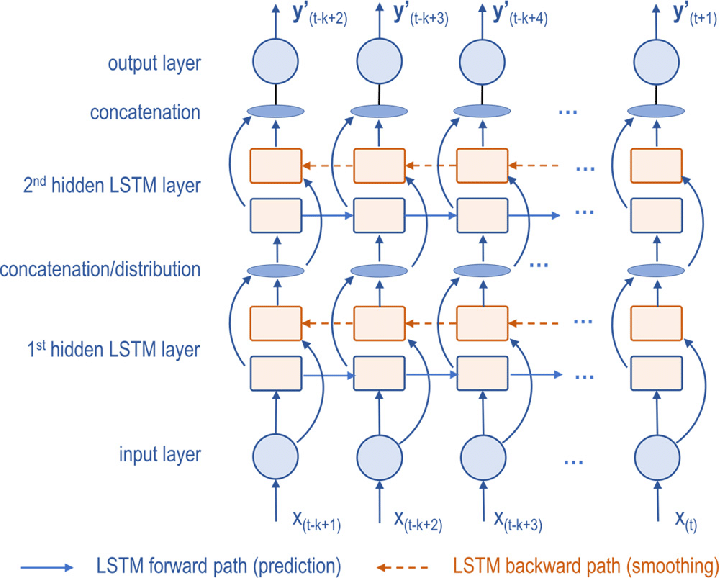
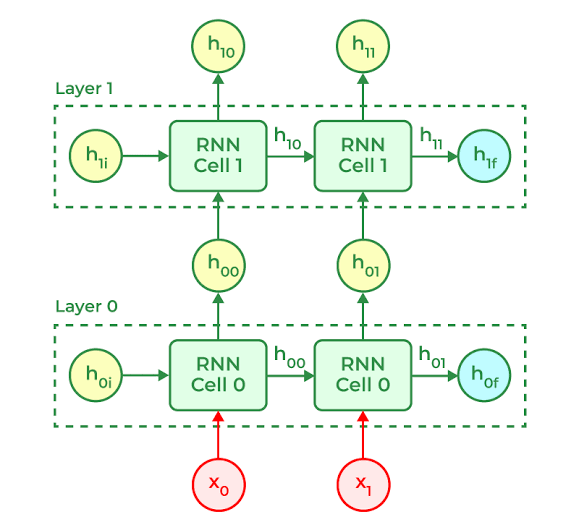


## Implementation
Practical implementation will be added here.

## Key Takeaways
- BiLSTM captures both past and future context for each token in a sequence.
- Stacked LSTMs learn hierarchical, increasingly abstract sequence representations.
- BiLSTM output doubles the hidden dimension due to forward-backward concatenation.
- Use `return_sequences=True` in Keras for all but the last layer in a stacked LSTM.
- BiLSTM + CRF is the classic architecture for sequence labeling tasks like NER.

## BI-LSTM Implementation

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, Dense

# Define the input shape
timesteps = 5  # Number of time steps
features = 10  # Number of features at each time step
output_size = 1  # Number of output units

# Generate some dummy data (random for now)
X = np.random.random((100, timesteps, features))  # 100 samples
y = np.random.random((100, output_size))  # 100 target values

# Create the Bi-LSTM model
model_bi_lstm = Sequential()
model_bi_lstm.add(Bidirectional(LSTM(64, return_sequences=False), input_shape=(timesteps, features)))
model_bi_lstm.add(Dense(output_size))

# Compile the model
model_bi_lstm.compile(optimizer='adam', loss='mse')

# Train the model
model_bi_lstm.fit(X, y, epochs=10, batch_size=32)

# Predict with the model
predictions_bi_lstm = model_bi_lstm.predict(X)
print(predictions_bi_lstm[:5])  # Show first 5 predictions

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - loss: 0.2423
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0727 
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.1090
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0765
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0738
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0866
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0893
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0736
Epoch 9/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0702
Epoch 10/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0737
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 192ms/step
[[0.5713039 ]
 [0.5816487 ]
 [0.55471337]
 [0.53155684]
 [0.52153945]]


In this code:

We define a Bi-LSTM using Bidirectional(LSTM(...)).

The model is compiled using Adam optimizer and Mean Squared Error (MSE) loss.

Dummy data is generated with random values for training, and predictions are made.

## Stacked LSTM Implementation

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Define the input shape
timesteps = 5  # Number of time steps
features = 10  # Number of features at each time step
output_size = 1  # Number of output units

# Generate some dummy data (random for now)
X = np.random.random((100, timesteps, features))  # 100 samples
y = np.random.random((100, output_size))  # 100 target values

# Create the Stacked LSTM model
model_stacked_lstm = Sequential()
model_stacked_lstm.add(LSTM(64, return_sequences=True, input_shape=(timesteps, features)))  # First LSTM layer
model_stacked_lstm.add(LSTM(64, return_sequences=False))  # Second LSTM layer
model_stacked_lstm.add(Dense(output_size))

# Compile the model
model_stacked_lstm.compile(optimizer='adam', loss='mse')

# Train the model
model_stacked_lstm.fit(X, y, epochs=10, batch_size=32)

# Predict with the model
predictions_stacked_lstm = model_stacked_lstm.predict(X)
print(predictions_stacked_lstm[:5])  # Show first 5 predictions

Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.4134
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1825
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1049
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1204
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.1063
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0965
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.1129
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.1067
Epoch 9/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.1044
Epoch 10/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0914
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 416ms/step
[[0.51957095]
 [0.55568826]
 [0.5235974 ]
 [0.5267204 ]
 [0.53520334]]


In this code:

We define a Stacked LSTM with two LSTM layers. The first LSTM layer has return_sequences=True to pass sequences to the next LSTM layer.

The model is compiled and trained in a similar fashion as the Bi-LSTM.

## Bi-LSTM Sentiment Analysis

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Load the IMDB dataset (using the top 10000 words)
max_features = 10000  # Number of words to consider as features
maxlen = 100  # Maximum length of each sequence

# Load the data and split into training and test sets
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=max_features)

# Pad sequences to ensure uniform length
X_train = pad_sequences(X_train, maxlen=maxlen)
X_test = pad_sequences(X_test, maxlen=maxlen)

# Create the Bi-LSTM model for sentiment analysis
model_bi_lstm_nlp = Sequential()
model_bi_lstm_nlp.add(Embedding(input_dim=max_features, output_dim=128, input_length=maxlen))
model_bi_lstm_nlp.add(Bidirectional(LSTM(64, return_sequences=False)))
model_bi_lstm_nlp.add(Dense(1, activation='sigmoid'))  # Binary classification (positive/negative)

# Compile the model
model_bi_lstm_nlp.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
model_bi_lstm_nlp.fit(X_train, y_train, epochs=3, batch_size=64, validation_data=(X_test, y_test))

# Evaluate the model
score = model_bi_lstm_nlp.evaluate(X_test, y_test, batch_size=64)
print("Test loss:", score[0])
print("Test accuracy:", score[1])

# Make predictions on new data
predictions_bi_lstm_nlp = model_bi_lstm_nlp.predict(X_test[:5])
print(predictions_bi_lstm_nlp)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/3


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


391/391 ━━━━━━━━━━━━━━━━━━━━ 146s 362ms/step - accuracy: 0.7274 - loss: 0.5141 - val_accuracy: 0.8496 - val_loss: 0.3432
Epoch 2/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 140s 358ms/step - accuracy: 0.8977 - loss: 0.2571 - val_accuracy: 0.8455 - val_loss: 0.3483
Epoch 3/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 147s 371ms/step - accuracy: 0.9349 - loss: 0.1771 - val_accuracy: 0.8415 - val_loss: 0.3902
391/391 ━━━━━━━━━━━━━━━━━━━━ 29s 75ms/step - accuracy: 0.8389 - loss: 0.4002
Test loss: 0.3902069926261902
Test accuracy: 0.8415200114250183


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step
[[0.3280178 ]
 [0.9979152 ]
 [0.90813583]
 [0.65466946]
 [0.99994355]]


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Load the IMDB dataset (using the top 10000 words)
max_features = 10000  # Number of words to consider as features
maxlen = 100  # Maximum length of each sequence

# Load the data and split into training and test sets
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=max_features)

# Pad sequences to ensure uniform length
X_train = pad_sequences(X_train, maxlen=maxlen)
X_test = pad_sequences(X_test, maxlen=maxlen)

# Create the Stacked LSTM model for sentiment analysis
model_stacked_lstm_nlp = Sequential()
model_stacked_lstm_nlp.add(Embedding(input_dim=max_features, output_dim=128, input_length=maxlen))
model_stacked_lstm_nlp.add(LSTM(64, return_sequences=True))  # First LSTM layer
model_stacked_lstm_nlp.add(LSTM(64, return_sequences=False))  # Second LSTM layer
model_stacked_lstm_nlp.add(Dense(1, activation='sigmoid'))  # Binary classification (positive/negative)

# Compile the model
model_stacked_lstm_nlp.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
model_stacked_lstm_nlp.fit(X_train, y_train, epochs=3, batch_size=64, validation_data=(X_test, y_test))

# Evaluate the model
score = model_stacked_lstm_nlp.evaluate(X_test, y_test, batch_size=64)
print("Test loss:", score[0])
print("Test accuracy:", score[1])

# Make predictions on new data
predictions_stacked_lstm_nlp = model_stacked_lstm_nlp.predict(X_test[:5])
print(predictions_stacked_lstm_nlp)

Epoch 1/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 132s 324ms/step - accuracy: 0.7449 - loss: 0.4959 - val_accuracy: 0.8294 - val_loss: 0.3740
Epoch 2/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 128s 289ms/step - accuracy: 0.8980 - loss: 0.2582 - val_accuracy: 0.8433 - val_loss: 0.3614
Epoch 3/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 154s 320ms/step - accuracy: 0.9367 - loss: 0.1768 - val_accuracy: 0.8255 - val_loss: 0.4337
391/391 ━━━━━━━━━━━━━━━━━━━━ 28s 73ms/step - accuracy: 0.8263 - loss: 0.4326
Test loss: 0.43371984362602234
Test accuracy: 0.8254799842834473


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 594ms/step
[[0.05327048]
 [0.99595946]
 [0.92484504]
 [0.17401506]
 [0.99963224]]


Bi-LSTM is great for capturing context from both directions (left to right and right to left) in sequential data, making it suitable for tasks like sentiment analysis.

Stacked LSTM is useful for learning deeper hierarchical representations of sequential data, which can be beneficial for complex NLP tasks.